# Import models 

In [1]:
import os
import subprocess
import pandas as pd
import numpy as np
import optuna
from optuna.samplers import NSGAIIISampler
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import re

C:\Users\hp\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Simulator running script

In [2]:
# =========================
# PATHS
# =========================
ECLRUN_EXE = r"C:\ecl\macros\eclrun.exe"
BASE_DIR = r"C:\Users\hp\Desktop\Eclipsetimesteps"

DATA_FILE_NAME = "Egg_Model_ECL.DATA"
RSM_FILE_NAME = "Egg_Model_ECL.RSM"
RSM_PATH = os.path.join(BASE_DIR, "EGG_MODEL_ECL.RSM")

N_BLOCKS = 5
BLOCK_END_DAYS = 720  # end of each block (24*30)
TARGET_TIMES = [BLOCK_END_DAYS * i for i in range(1, N_BLOCKS + 1)]
FINAL_TIME = TARGET_TIMES[-1]

In [3]:
# =========================
# RUN ECLIPSE
# =========================
def run_eclipse():
    print("▶ Running Eclipse ...")
    cmd = [ECLRUN_EXE, "eclipse", DATA_FILE_NAME]
    subprocess.run(cmd, cwd=BASE_DIR, check=True)
    print("✔ Eclipse finished")

# =========================
# EXTRACT FOPT & FWPT PER BLOCK
# =========================
def extract_FOPT_FWPT_from_RSM(rsm_path):

    with open(rsm_path, "r") as f:
        lines = f.readlines()

    inside_summary = False
    fopt_idx = fwpt_idx = None

    for line in lines:

        if "SUMMARY OF RUN" in line:
            inside_summary = True
            fopt_idx = fwpt_idx = None
            continue

        if not inside_summary:
            continue

        tokens = line.split()
        if not tokens:
            continue

        # Detect column headers
        if fopt_idx is None and "FOPT" in tokens and "FWPT" in tokens:
            fopt_idx = tokens.index("FOPT")
            fwpt_idx = tokens.index("FWPT")
            continue

        if fopt_idx is None:
            continue

        # ✅ Only data rows have numeric TIME
        if not tokens[0][0].isdigit():
            continue
        if float(tokens[0]) == 3600.0:
            return float(tokens[fopt_idx]), float(tokens[fwpt_idx])

In [4]:
def modify_data_per_control_block(blocks_params):

    data_path = os.path.join(BASE_DIR, DATA_FILE_NAME)

    with open(data_path, "r") as f:
        lines = f.readlines()

    block_pattern = re.compile(r"--\s*Block\s+(\d+)", re.IGNORECASE)

    current_block = None
    new_lines = []

    for line in lines:

        # Detect block number
        m = block_pattern.search(line)
        if m:
            current_block = int(m.group(1))
            new_lines.append(line)
            continue

        # Skip if block not in params
        if current_block is None or current_block > len(blocks_params):
            new_lines.append(line)
            continue

        params = blocks_params[current_block - 1]
        stripped = line.strip()

        # -------------------------
        # PRODUCER BHP
        # -------------------------
        prod_match = re.match(r"'PROD(\d+)'", stripped)
        if prod_match and "'BHP'" in stripped:

            prod_num = prod_match.group(1)
            key = f"BHP{prod_num}"

            if key in params:
                bhp_value = int(params[key])

                # Replace last numeric value in line (robust)
                line = re.sub(r"(5\*\s*)(\d+)", rf"\g<1>{bhp_value}", line)

        # -------------------------
        # INJECTOR RATE
        # -------------------------
        inj_match = re.match(r"'INJECT(\d+)'", stripped)
        if inj_match and "'RATE'" in stripped:

            inj_num = inj_match.group(1)
            key = f"inj_rate{inj_num}"

            if key in params:
                rate_value = int(params[key])

                # Replace RATE value robustly
                line = re.sub(r"('RATE'\s+)(\d+)", rf"\g<1>{rate_value}", line)

        new_lines.append(line)

    with open(data_path, "w") as f:
        f.writelines(new_lines)

# Define objective optimization function

In [5]:
def objective(trial):

    # 1) Suggest parameters per control block
    blocks_params = []
    for b in range(1, N_BLOCKS + 1):
        blocks_params.append({
            "BHP1": trial.suggest_int(f"BHP1_b{b}", 150, 390),
            "BHP2": trial.suggest_int(f"BHP2_b{b}", 150, 390),
            "BHP3": trial.suggest_int(f"BHP3_b{b}", 150, 390),
            "BHP4": trial.suggest_int(f"BHP4_b{b}", 150, 390),
            "inj_rate1": trial.suggest_int(f"inj_rate1_b{b}", 50, 400),
            "inj_rate2": trial.suggest_int(f"inj_rate2_b{b}", 50, 400),
            "inj_rate3": trial.suggest_int(f"inj_rate3_b{b}", 50, 400),
            "inj_rate4": trial.suggest_int(f"inj_rate4_b{b}", 50, 400),
            "inj_rate5": trial.suggest_int(f"inj_rate5_b{b}", 50, 400),
            "inj_rate6": trial.suggest_int(f"inj_rate6_b{b}", 50, 400),
            "inj_rate7": trial.suggest_int(f"inj_rate7_b{b}", 50, 400),
            "inj_rate8": trial.suggest_int(f"inj_rate8_b{b}", 50, 400),
        })

    # 2) Update schedule per CONTROL BLOCK (BHP + RATE)
    modify_data_per_control_block(blocks_params)

    run_eclipse()
    # 3) Extract FOPT/FWPT at block end times
    fopt, fwpt = extract_FOPT_FWPT_from_RSM(RSM_PATH)
    return fopt, fwpt

# Optimization running 

In [7]:
sampler = optuna.samplers.TPESampler(
    n_startup_trials=42,
    multivariate=False,
    seed=42)

study = optuna.create_study(
    directions=["maximize", "minimize"],
    sampler=sampler,
    study_name="ECLIPSE_SUM_DELTA_FOPT_FWPT"
)

study.optimize(objective, n_trials=300, show_progress_bar=False)

[I 2026-03-23 18:34:45,079] A new study created in memory with name: ECLIPSE_SUM_DELTA_FOPT_FWPT


▶ Running Eclipse ...


[I 2026-03-23 18:35:58,645] Trial 0 finished with values: [543062.1, 5438268.0] and parameters: {'BHP1_b1': 240, 'BHP2_b1': 379, 'BHP3_b1': 326, 'BHP4_b1': 294, 'inj_rate1_b1': 104, 'inj_rate2_b1': 104, 'inj_rate3_b1': 70, 'inj_rate4_b1': 354, 'inj_rate5_b1': 260, 'inj_rate6_b1': 298, 'inj_rate7_b1': 57, 'inj_rate8_b1': 390, 'BHP1_b2': 350, 'BHP2_b2': 201, 'BHP3_b2': 193, 'BHP4_b2': 194, 'inj_rate1_b2': 156, 'inj_rate2_b2': 234, 'inj_rate3_b2': 201, 'inj_rate4_b2': 152, 'inj_rate5_b2': 264, 'inj_rate6_b2': 98, 'inj_rate7_b2': 152, 'inj_rate8_b2': 178, 'BHP1_b3': 259, 'BHP2_b3': 339, 'BHP3_b3': 198, 'BHP4_b3': 273, 'inj_rate1_b3': 257, 'inj_rate2_b3': 66, 'inj_rate3_b3': 263, 'inj_rate4_b3': 109, 'inj_rate5_b3': 72, 'inj_rate6_b3': 383, 'inj_rate7_b3': 388, 'inj_rate8_b3': 333, 'BHP1_b4': 223, 'BHP2_b4': 173, 'BHP3_b4': 314, 'BHP4_b4': 256, 'inj_rate1_b4': 92, 'inj_rate2_b4': 223, 'inj_rate3_b4': 62, 'inj_rate4_b4': 369, 'inj_rate5_b4': 140, 'inj_rate6_b4': 282, 'inj_rate7_b4': 159, 'in

✔ Eclipse finished
▶ Running Eclipse ...


[I 2026-03-23 18:37:11,248] Trial 1 finished with values: [547082.7, 6253821.0] and parameters: {'BHP1_b1': 243, 'BHP2_b1': 215, 'BHP3_b1': 349, 'BHP4_b1': 235, 'inj_rate1_b1': 148, 'inj_rate2_b1': 240, 'inj_rate3_b1': 99, 'inj_rate4_b1': 331, 'inj_rate5_b1': 76, 'inj_rate6_b1': 396, 'inj_rate7_b1': 321, 'inj_rate8_b1': 119, 'BHP1_b2': 151, 'BHP2_b2': 346, 'BHP3_b2': 320, 'BHP4_b2': 325, 'inj_rate1_b2': 320, 'inj_rate2_b2': 75, 'inj_rate3_b2': 175, 'inj_rate4_b2': 90, 'inj_rate5_b2': 352, 'inj_rate6_b2': 268, 'inj_rate7_b2': 166, 'inj_rate8_b2': 72, 'BHP1_b3': 224, 'BHP2_b3': 228, 'BHP3_b3': 325, 'BHP4_b3': 303, 'inj_rate1_b3': 361, 'inj_rate2_b3': 215, 'inj_rate3_b3': 91, 'inj_rate4_b3': 300, 'inj_rate5_b3': 317, 'inj_rate6_b3': 247, 'inj_rate7_b3': 320, 'inj_rate8_b3': 223, 'BHP1_b4': 275, 'BHP2_b4': 253, 'BHP3_b4': 156, 'BHP4_b4': 176, 'inj_rate1_b4': 61, 'inj_rate2_b4': 273, 'inj_rate3_b4': 160, 'inj_rate4_b4': 228, 'inj_rate5_b4': 368, 'inj_rate6_b4': 137, 'inj_rate7_b4': 194, 'in

...

✔ Eclipse finished
▶ Running Eclipse ...


[I 2026-03-24 06:02:22,994] Trial 298 finished with values: [518881.3, 2439212.0] and parameters: {'BHP1_b1': 190, 'BHP2_b1': 177, 'BHP3_b1': 347, 'BHP4_b1': 156, 'inj_rate1_b1': 253, 'inj_rate2_b1': 171, 'inj_rate3_b1': 242, 'inj_rate4_b1': 195, 'inj_rate5_b1': 279, 'inj_rate6_b1': 197, 'inj_rate7_b1': 56, 'inj_rate8_b1': 56, 'BHP1_b2': 380, 'BHP2_b2': 274, 'BHP3_b2': 258, 'BHP4_b2': 229, 'inj_rate1_b2': 192, 'inj_rate2_b2': 367, 'inj_rate3_b2': 235, 'inj_rate4_b2': 85, 'inj_rate5_b2': 348, 'inj_rate6_b2': 174, 'inj_rate7_b2': 75, 'inj_rate8_b2': 128, 'BHP1_b3': 214, 'BHP2_b3': 331, 'BHP3_b3': 213, 'BHP4_b3': 259, 'inj_rate1_b3': 174, 'inj_rate2_b3': 78, 'inj_rate3_b3': 199, 'inj_rate4_b3': 88, 'inj_rate5_b3': 358, 'inj_rate6_b3': 50, 'inj_rate7_b3': 342, 'inj_rate8_b3': 150, 'BHP1_b4': 276, 'BHP2_b4': 346, 'BHP3_b4': 282, 'BHP4_b4': 150, 'inj_rate1_b4': 56, 'inj_rate2_b4': 365, 'inj_rate3_b4': 157, 'inj_rate4_b4': 238, 'inj_rate5_b4': 109, 'inj_rate6_b4': 97, 'inj_rate7_b4': 65, 'inj

✔ Eclipse finished
▶ Running Eclipse ...


[I 2026-03-24 06:04:33,768] Trial 299 finished with values: [540746.2, 4261339.0] and parameters: {'BHP1_b1': 198, 'BHP2_b1': 172, 'BHP3_b1': 204, 'BHP4_b1': 155, 'inj_rate1_b1': 322, 'inj_rate2_b1': 161, 'inj_rate3_b1': 235, 'inj_rate4_b1': 244, 'inj_rate5_b1': 167, 'inj_rate6_b1': 188, 'inj_rate7_b1': 50, 'inj_rate8_b1': 52, 'BHP1_b2': 269, 'BHP2_b2': 286, 'BHP3_b2': 275, 'BHP4_b2': 220, 'inj_rate1_b2': 204, 'inj_rate2_b2': 382, 'inj_rate3_b2': 281, 'inj_rate4_b2': 100, 'inj_rate5_b2': 366, 'inj_rate6_b2': 209, 'inj_rate7_b2': 94, 'inj_rate8_b2': 137, 'BHP1_b3': 212, 'BHP2_b3': 338, 'BHP3_b3': 204, 'BHP4_b3': 268, 'inj_rate1_b3': 165, 'inj_rate2_b3': 68, 'inj_rate3_b3': 185, 'inj_rate4_b3': 58, 'inj_rate5_b3': 365, 'inj_rate6_b3': 57, 'inj_rate7_b3': 333, 'inj_rate8_b3': 160, 'BHP1_b4': 286, 'BHP2_b4': 382, 'BHP3_b4': 289, 'BHP4_b4': 155, 'inj_rate1_b4': 67, 'inj_rate2_b4': 384, 'inj_rate3_b4': 146, 'inj_rate4_b4': 79, 'inj_rate5_b4': 297, 'inj_rate6_b4': 107, 'inj_rate7_b4': 387, 'i

✔ Eclipse finished


In [8]:
pareto = study.best_trials  # Pareto front

for i, t in enumerate(pareto[:10], start=1):
    print(f"\n--- Pareto solution {i} ---")
    print("ΣΔFOPT:", t.values[0], " ΣΔFWPT:", t.values[1])
    # print some parameters
    for k in sorted(t.params.keys()):
        print(k, "=", t.params[k])


--- Pareto solution 1 ---
ΣΔFOPT: 546235.2  ΣΔFWPT: 5143534.0
BHP1_b1 = 153
BHP1_b2 = 200
BHP1_b3 = 246
BHP1_b4 = 322
BHP1_b5 = 173
BHP2_b1 = 309
BHP2_b2 = 366
BHP2_b3 = 284
BHP2_b4 = 308
BHP2_b5 = 208
BHP3_b1 = 192
BHP3_b2 = 199
BHP3_b3 = 187
BHP3_b4 = 156
BHP3_b5 = 324
BHP4_b1 = 381
BHP4_b2 = 195
BHP4_b3 = 193
BHP4_b4 = 203
BHP4_b5 = 356
inj_rate1_b1 = 102
inj_rate1_b2 = 62
inj_rate1_b3 = 352
inj_rate1_b4 = 131
inj_rate1_b5 = 341
inj_rate2_b1 = 195
inj_rate2_b2 = 215
inj_rate2_b3 = 382
inj_rate2_b4 = 285
inj_rate2_b5 = 189
inj_rate3_b1 = 79
inj_rate3_b2 = 248
inj_rate3_b3 = 181
inj_rate3_b4 = 56
inj_rate3_b5 = 284
inj_rate4_b1 = 399
inj_rate4_b2 = 73
inj_rate4_b3 = 145
inj_rate4_b4 = 86
inj_rate4_b5 = 121
inj_rate5_b1 = 226
inj_rate5_b2 = 322
inj_rate5_b3 = 276
inj_rate5_b4 = 330
inj_rate5_b5 = 152
inj_rate6_b1 = 258
inj_rate6_b2 = 209
inj_rate6_b3 = 193
inj_rate6_b4 = 112
inj_rate6_b5 = 364
inj_rate7_b1 = 73
inj_rate7_b2 = 234
inj_rate7_b3 = 58
inj_rate7_b4 = 279
inj_rate7_b5 = 54


# The plot of FOPT & FWPT  for the base case:

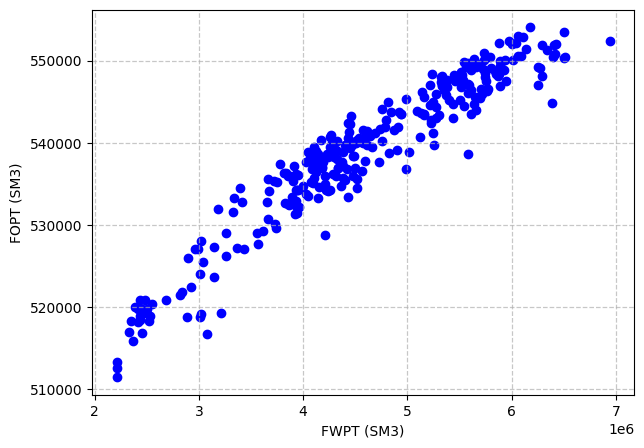

In [10]:
import matplotlib.pyplot as plt
pareto_trials1 = study.best_trials
fopts1 = [t.values[0] for t in study.trials if t.values is not None]
fwpts1 = [t.values[1] for t in study.trials if t.values is not None]

plt.figure(figsize=(7,5),dpi=100)
plt.scatter(fwpts1, fopts1, c='blue')
plt.xlabel("FWPT (SM3)")
plt.ylabel("FOPT (SM3)")
plt.grid(True, which="major", linestyle="--", linewidth=0.9, alpha=0.7)
plt.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.4)
plt.show()

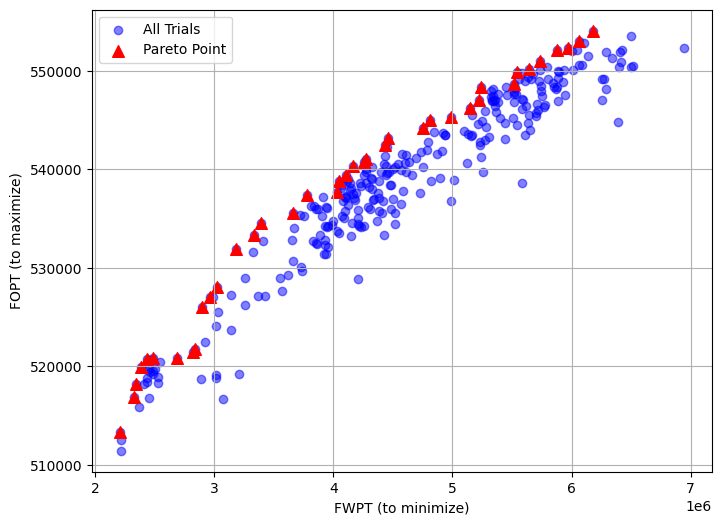

In [20]:
# --- Pareto optimal trials ---
pareto_trials1 = study.best_trials
pareto_fopts = [t.values[0] for t in pareto_trials1]
pareto_fwpts = [t.values[1] for t in pareto_trials1]

# --- Sort Pareto points by FWPT (minimization axis) ---
pareto_points = sorted(zip(pareto_fwpts, pareto_fopts))
pareto_fwpts_sorted, pareto_fopts_sorted = zip(*pareto_points)
pareto_trials = study.best_trials
fopts = [t.values[0] for t in study.trials if t.values is not None]
fwpts = [t.values[1] for t in study.trials if t.values is not None]
plt.figure(figsize=(8,6))

# All solutions
plt.scatter(fwpts, fopts, color='blue', alpha=0.5, label='All Trials')

# Pareto points 
mid_index = len(pareto_fwpts_sorted)//2
# First half: red triangles
plt.scatter(pareto_fwpts_sorted, pareto_fopts_sorted,
            color='red', marker='^', s=70, label='Pareto Point')


plt.xlabel("FWPT (to minimize)")
plt.ylabel("FOPT (to maximize)")
plt.legend()
plt.grid(True)
plt.show()

# Pareto front optimal results

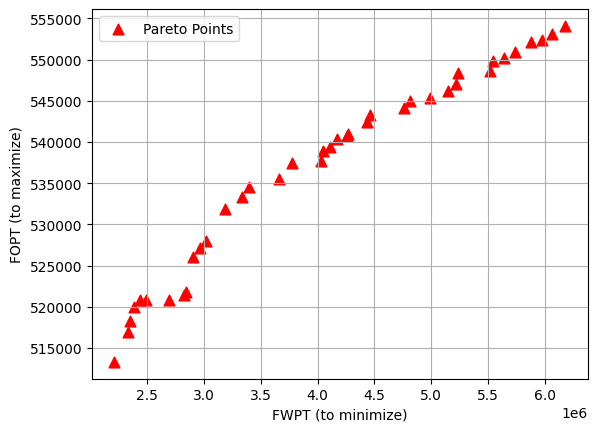

In [15]:
plt.figure()
# Pareto points
plt.scatter(pareto_fwpts_sorted, pareto_fopts_sorted,
            color='red', s=60, label='Pareto Points', marker='^')
plt.xlabel("FWPT (to minimize)")
plt.ylabel("FOPT (to maximize)")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
print("\nPareto Front Table\n")
print("Trial\tFOPT\tFWPT")

for trial in pareto_trials:
    print(f"{trial.number}\t{trial.values[0]:.2f}\t{trial.values[1]:.2f}")


Pareto Front Table

Trial	FOPT	FWPT
14	546235.20	5143534.00
42	521430.90	2822526.00
48	539443.40	4108335.00
52	535567.70	3662482.00
55	537706.70	4027268.00
64	537408.40	3775632.00
69	545330.40	4987559.00
70	550195.10	5641588.00
81	552123.80	5881042.00
83	520833.40	2687768.00
92	548658.30	5518884.00
105	540344.40	4168661.00
118	548327.70	5239144.00
159	554076.70	6180170.00
163	521796.60	2841827.00
166	538869.20	4049401.00
168	549851.20	5540930.00
169	534519.20	3397655.00
170	544163.20	4756956.00
171	553067.70	6059798.00
173	544982.10	4810183.00
174	552370.50	5972066.00
176	533319.70	3334448.00
178	528018.90	3020980.00
181	527091.70	2964410.00
182	531906.80	3180667.00
201	542434.80	4434800.00
213	547086.40	5220478.00
231	550972.00	5738268.00
240	526021.10	2900584.00
245	543236.70	4456260.00
261	541009.10	4270982.00
278	513322.40	2210827.00
282	516940.40	2326064.00
283	520822.70	2487040.00
286	520800.10	2439548.00
287	519945.90	2386346.00
290	518265.70	2346290.00
299	540746.20	4261339.00

In [17]:
# ===============================
# Constraint definition
# ===============================
FWPT_max = 6900000  # constraint on water production

# Extract Pareto values
fopt = np.array([t.values[0] for t in pareto_trials])
fwpt = np.array([t.values[1] for t in pareto_trials])

# ===============================
# Apply constraint (FWPT <= limit)
# ===============================
valid_indices = [i for i, fw in enumerate(fwpt) if fw <= FWPT_max]

if valid_indices:

    # Select best FOPT among valid ones
    best_idx = max(valid_indices, key=lambda i: fopt[i])
    best_trial_constraint = pareto_trials[best_idx]

    # --- Extract values ---
    best_fopt = best_trial_constraint.values[0]
    best_fwpt = best_trial_constraint.values[1]
    params = best_trial_constraint.params

    # --- Separate BHP and Injection rates ---
    bhp_params = {k: v for k, v in params.items() if "BHP" in k}
    inj_params = {k: v for k, v in params.items() if "inj" in k.lower()}

    # --- Print results ---
    print("========== CONSTRAINED OPTIMAL SOLUTION ==========")
    print(f"Trial Number : {best_trial_constraint.number}")
    print(f"FOPT         : {best_fopt}")
    print(f"FWPT         : {best_fwpt}")

    print("\n--- BHP Parameters ---")
    for k, v in bhp_params.items():
        print(f"{k}: {v}")

    print("\n--- Injection Rate Parameters ---")
    for k, v in inj_params.items():
        print(f"{k}: {v}")

else:
    print("No Pareto solution satisfies the FWPT constraint.")

========== CONSTRAINED OPTIMAL SOLUTION ==========
Trial Number : 159
FOPT         : 554076.7
FWPT         : 6180170.0

--- BHP Parameters ---
BHP1_b1: 386
BHP2_b1: 189
BHP3_b1: 215
BHP4_b1: 159
BHP1_b2: 272
BHP2_b2: 254
BHP3_b2: 231
BHP4_b2: 232
BHP1_b3: 195
BHP2_b3: 342
BHP3_b3: 207
BHP4_b3: 271
BHP1_b4: 276
BHP2_b4: 355
BHP3_b4: 327
BHP4_b4: 216
BHP1_b5: 309
BHP2_b5: 390
BHP3_b5: 275
BHP4_b5: 291

--- Injection Rate Parameters ---
inj_rate1_b1: 268
inj_rate2_b1: 161
inj_rate3_b1: 153
inj_rate4_b1: 140
inj_rate5_b1: 50
inj_rate6_b1: 370
inj_rate7_b1: 194
inj_rate8_b1: 312
inj_rate1_b2: 229
inj_rate2_b2: 325
inj_rate3_b2: 362
inj_rate4_b2: 92
inj_rate5_b2: 317
inj_rate6_b2: 283
inj_rate7_b2: 105
inj_rate8_b2: 174
inj_rate1_b3: 197
inj_rate2_b3: 271
inj_rate3_b3: 365
inj_rate4_b3: 239
inj_rate5_b3: 326
inj_rate6_b3: 255
inj_rate7_b3: 339
inj_rate8_b3: 124
inj_rate1_b4: 194
inj_rate2_b4: 377
inj_rate3_b4: 216
inj_rate4_b4: 215
inj_rate5_b4: 218
inj_rate6_b4: 187
inj_rate7_b4: 400
inj_ra

# Best optimal with contraint

In [19]:
# ===============================
# Constraint definition
# ===============================
FWPT_max = 5900000  # constraint on water production

# Extract Pareto values
fopt = np.array([t.values[0] for t in pareto_trials])
fwpt = np.array([t.values[1] for t in pareto_trials])

# ===============================
# Apply constraint (FWPT <= limit)
# ===============================
valid_indices = [i for i, fw in enumerate(fwpt) if fw <= FWPT_max]

if valid_indices:

    # Select best FOPT among valid ones
    best_idx = max(valid_indices, key=lambda i: fopt[i])
    best_trial_constraint = pareto_trials[best_idx]

    # --- Extract values ---
    best_fopt = best_trial_constraint.values[0]
    best_fwpt = best_trial_constraint.values[1]
    params = best_trial_constraint.params

    # --- Separate BHP and Injection rates ---
    bhp_params = {k: v for k, v in params.items() if "BHP" in k}
    inj_params = {k: v for k, v in params.items() if "inj" in k.lower()}

    # --- Print results ---
    print("========== CONSTRAINED OPTIMAL SOLUTION ==========")
    print(f"Trial Number : {best_trial_constraint.number}")
    print(f"FOPT         : {best_fopt}")
    print(f"FWPT         : {best_fwpt}")

    print("\n--- BHP Parameters ---")
    for k, v in bhp_params.items():
        print(f"{k}: {v}")

    print("\n--- Injection Rate Parameters ---")
    for k, v in inj_params.items():
        print(f"{k}: {v}")

else:
    print("No Pareto solution satisfies the FWPT constraint.")

========== CONSTRAINED OPTIMAL SOLUTION ==========
Trial Number : 81
FOPT         : 552123.8
FWPT         : 5881042.0

--- BHP Parameters ---
BHP1_b1: 192
BHP2_b1: 321
BHP3_b1: 211
BHP4_b1: 201
BHP1_b2: 374
BHP2_b2: 252
BHP3_b2: 232
BHP4_b2: 266
BHP1_b3: 230
BHP2_b3: 378
BHP3_b3: 233
BHP4_b3: 244
BHP1_b4: 268
BHP2_b4: 359
BHP3_b4: 162
BHP4_b4: 179
BHP1_b5: 301
BHP2_b5: 368
BHP3_b5: 164
BHP4_b5: 315

--- Injection Rate Parameters ---
inj_rate1_b1: 311
inj_rate2_b1: 265
inj_rate3_b1: 165
inj_rate4_b1: 63
inj_rate5_b1: 61
inj_rate6_b1: 250
inj_rate7_b1: 368
inj_rate8_b1: 360
inj_rate1_b2: 218
inj_rate2_b2: 330
inj_rate3_b2: 397
inj_rate4_b2: 59
inj_rate5_b2: 390
inj_rate6_b2: 220
inj_rate7_b2: 206
inj_rate8_b2: 196
inj_rate1_b3: 292
inj_rate2_b3: 319
inj_rate3_b3: 370
inj_rate4_b3: 124
inj_rate5_b3: 314
inj_rate6_b3: 184
inj_rate7_b3: 174
inj_rate8_b3: 110
inj_rate1_b4: 221
inj_rate2_b4: 295
inj_rate3_b4: 248
inj_rate4_b4: 97
inj_rate5_b4: 94
inj_rate6_b4: 91
inj_rate7_b4: 77
inj_rate8_b4

In [27]:
params = best_trial_knee.params
data = {}

for key, value in params.items():
    name, block = key.rsplit('_', 1)   # split at last underscore

    if block not in data:
        data[block] = {}

    data[block][name] = value
import pandas as pd

df_knee = pd.DataFrame.from_dict(data, orient='index')

# Sort columns and rows (optional but cleaner)
df_knee = df_knee.reindex(sorted(df_knee.columns), axis=1)
df_knee = df_knee.sort_index()

print(df_knee)

    BHP1  BHP2  BHP3  BHP4  inj_rate1  inj_rate2  inj_rate3  inj_rate4  \
b1   386   189   215   159        268        161        153        140   
b2   272   254   231   232        229        325        362         92   
b3   195   342   207   271        197        271        365        239   
b4   276   355   327   216        194        377        216        215   
b5   309   390   275   291        135        203        234        221   

    inj_rate5  inj_rate6  inj_rate7  inj_rate8  
b1         50        370        194        312  
b2        317        283        105        174  
b3        326        255        339        124  
b4        218        187        400        177  
b5        128        150        269        377  
